# Comparativa global

Vista de pájaro de todos los runs. Incluye:
- **Matriz experimental**: qué combinaciones modelo × motor × config se han medido.
- **Tabla resumen**: un row por run con factores y métricas agregadas.
- **Eficiencia energética**: potencia media vs throughput (frente de Pareto).
- **Alertas**: runs con throttling, generaciones vacías, anomalías.

Este notebook es el que se defiende ante el tribunal.

In [1]:
"""Carga de todos los runs."""

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from monitorviz.io import load_collection
from monitorviz.viz import setup_style

setup_style("talk")
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == "notebooks" else _here
DATA_ROOT = PROJECT_ROOT / "data" / "raw_runs"

assert DATA_ROOT.is_dir(), f"❌ No encontrado: {DATA_ROOT.resolve()}"

coll = load_collection(DATA_ROOT)
print(f"Runs cargados: {len(coll)}")

tokenProb size mismatch in run=mnistral prompt=0: got 836 tokens, eval_count=849


Runs cargados: 4


## Matriz experimental

Qué combinaciones de modelo × motor × fan × acelerador se han medido.
Las casillas vacías o con 0 indican combinaciones pendientes de ejecutar.

In [2]:
matrix = coll.experiment_matrix()
matrix

,model_short,engine,fan,accelerator,n_runs
0,gemma3n:e2b,OLLAMA,True,False,1
1,granite4:micro-h,OLLAMA,True,False,1
2,ministral-3:3b,OLLAMA,True,False,1
3,tinyllama-1.1b-chat-v1.0.Q4_0,LLAMA,True,False,1


## Tabla resumen

Un row por run con todos los factores experimentales y métricas
agregadas: throughput, latencia, perplejidad, temperatura máxima,
potencia media, energía por token y ratio de throttling.

Esta tabla es la base de las gráficas comparativas que siguen.

In [3]:
summary = coll.summary_df()

display_cols = [
    "model_label", "engine", "test_type",
    "batch_size", "context_size", "temperature",
    "fan", "accelerator",
    "n_prompts", "n_empty_generations",
    "tokens_per_s_mean", "words_per_s_mean",
    "latency_ms_mean", "ttft_ms_mean",
    "perplexity_geomean",
    "flops_decode_gflops",
    "mbu_pct",
    "model_size_gb",
    "temp_max_c", "temp_mean_c",
    "power_mean_w", "power_max_w",
    "energy_per_token_j",
    "throttled_ratio",
]
cols = [c for c in display_cols if c in summary.columns]
summary[cols].round(3)


,model_label,engine,test_type,batch_size,context_size,temperature,fan,accelerator,n_prompts,n_empty_generations,tokens_per_s_mean,words_per_s_mean,latency_ms_mean,ttft_ms_mean,perplexity_geomean,flops_decode_gflops,mbu_pct,model_size_gb,temp_max_c,temp_mean_c,power_mean_w,power_max_w,energy_per_token_j,throttled_ratio
0,gemma,OLLAMA,TYPE_1,512,4096,0.7,True,False,1,0,5.972,4.713,156154.222,78443.597,1.226,53.228,48.309,2.507,83.15,68.738,5.663,9.547,0.948,0.217
1,granite,OLLAMA,TYPE_1,512,4096,0.7,True,False,1,0,4.522,3.786,111492.256,13510.203,2.087,28.865,NaN,1.795,81.50,77.988,8.100,9.567,1.791,0.000
2,ministral,OLLAMA,TYPE_1,512,4096,0.7,True,False,1,0,3.553,2.825,355270.605,112677.706,2.348,27.354,25.970,2.165,84.25,78.139,7.610,9.582,2.142,0.280
3,tinyllama,LLAMA,TYPE_1,512,4096,0.7,True,False,7,3,4.597,3.823,8118.316,1141.728,2.554,10.115,9.841,0.638,79.30,74.003,7.560,9.075,1.644,0.000


## MBU — Model Bandwidth Utilization

El MBU mide qué fracción del ancho de banda de memoria del dispositivo se
utiliza realmente durante la inferencia. Un MBU cercano al 100% indica que
la inferencia está limitada por el ancho de banda de memoria (memory-bound),
que es el caso típico de la decodificación secuencial en LLMs sobre CPU.

Fórmula (Chen et al., 2025 — ELIB):
```
MBU = (Model_Size + KV_Cache) / TPOT / Peak_Bandwidth × 100%
```
Peak bandwidth para RPi5 (LPDDR4X-4267, 64-bit): 34.1 GB/s.


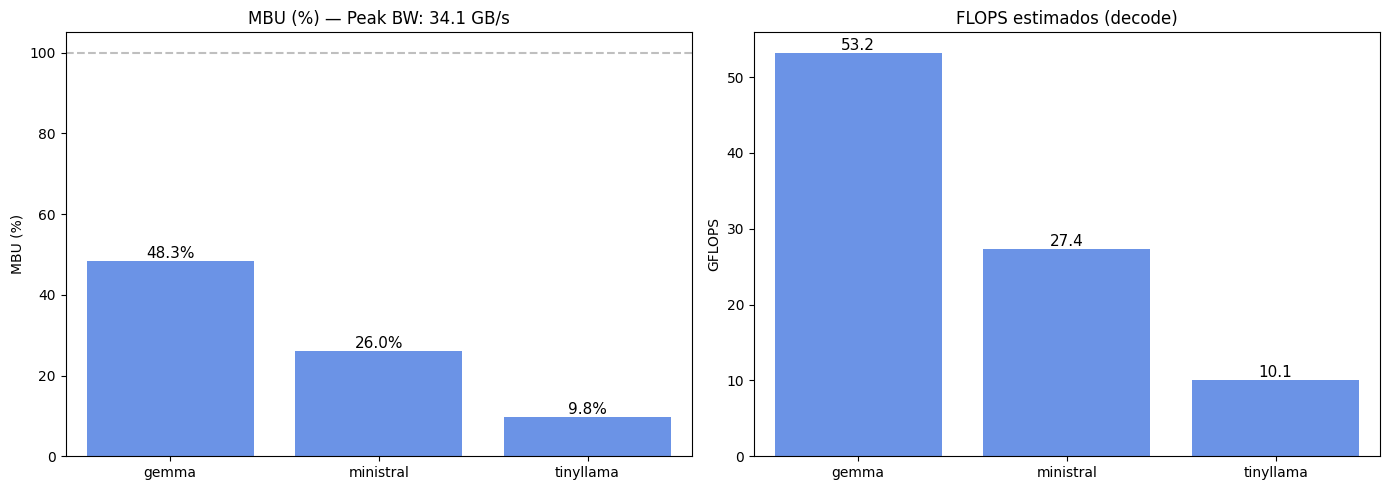


Nota: FLOPS estimados = 2 × n_params × tokens/s (aproximación estándar).
Peak bandwidth objetivo: 34.1 GB/s (RPi5 LPDDR4X-4267).


In [4]:
from monitorviz.viz import TARGET_PEAK_MEMORY_BANDWIDTH_GBs

mbu_data = summary.dropna(subset=["mbu_pct", "flops_decode_gflops"])

if mbu_data.empty:
    print(
        "Sin datos de MBU/FLOPS — requiere model_info con n_kv_heads y "
        "bits_per_weight. Regenera los runs con el MonitorSystem actualizado."
    )
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    order = mbu_data.sort_values("mbu_pct", ascending=False)["model_label"].tolist()

    sns.barplot(data=mbu_data, x="model_label", y="mbu_pct",
                order=order, ax=axes[0])
    axes[0].set_title(f"MBU (%) — Peak BW: {TARGET_PEAK_MEMORY_BANDWIDTH_GBs} GB/s")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("MBU (%)")
    axes[0].axhline(100, ls="--", color="gray", alpha=0.5)
    for p in axes[0].patches:
        axes[0].annotate(f"{p.get_height():.1f}%",
                         (p.get_x() + p.get_width() / 2, p.get_height()),
                         ha="center", va="bottom", fontsize=11)

    sns.barplot(data=mbu_data, x="model_label", y="flops_decode_gflops",
                order=order, ax=axes[1])
    axes[1].set_title("FLOPS estimados (decode)")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("GFLOPS")
    for p in axes[1].patches:
        axes[1].annotate(f"{p.get_height():.1f}",
                         (p.get_x() + p.get_width() / 2, p.get_height()),
                         ha="center", va="bottom", fontsize=11)

    fig.tight_layout()
    plt.show()
    print(f"\nNota: FLOPS estimados = 2 × n_params × tokens/s (aproximación estándar).")
    print(f"Peak bandwidth objetivo: {TARGET_PEAK_MEMORY_BANDWIDTH_GBs} GB/s (RPi5 LPDDR4X-4267).")


## Throughput por modelo

Comparativa directa de tokens/s y palabras/s entre modelos. El boxplot
muestra la variabilidad entre prompts dentro de cada modelo.

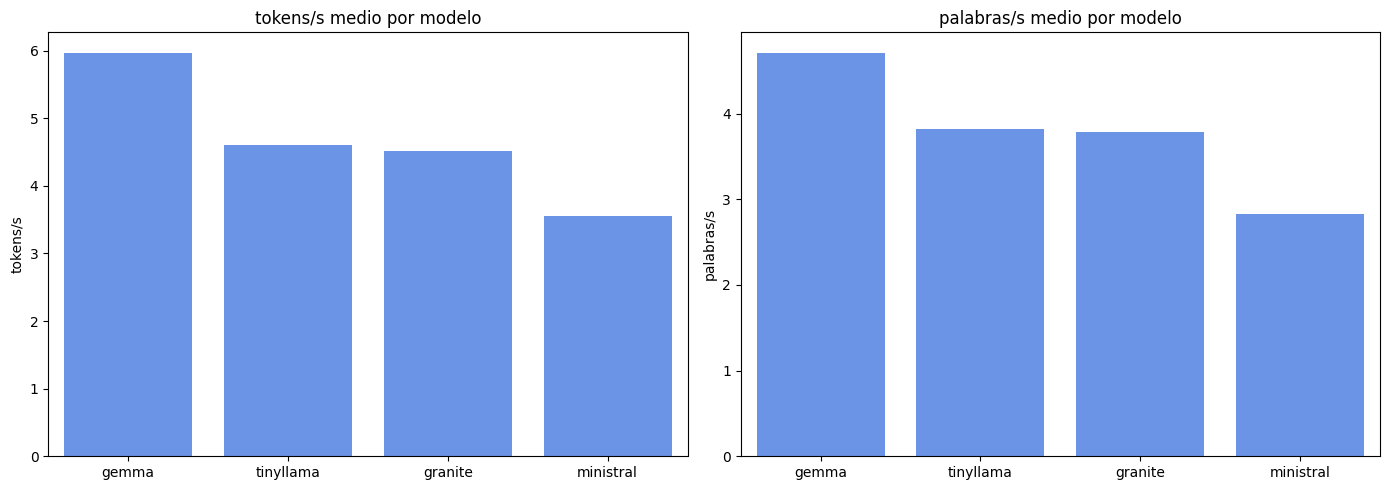

In [5]:
summary_sorted = summary.sort_values("tokens_per_s_mean", ascending=False)
order = summary_sorted["model_label"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=summary, x="model_label", y="tokens_per_s_mean",
            order=order, ax=axes[0])
axes[0].set_title("tokens/s medio por modelo")
axes[0].set_xlabel("")
axes[0].set_ylabel("tokens/s")

sns.barplot(data=summary, x="model_label", y="words_per_s_mean",
            order=order, ax=axes[1])
axes[1].set_title("palabras/s medio por modelo")
axes[1].set_xlabel("")
axes[1].set_ylabel("palabras/s")

fig.tight_layout()
plt.show()


## Eficiencia energética

Relación entre potencia consumida y throughput. Los modelos más eficientes
están **arriba-izquierda** (alto throughput, baja potencia). Los menos
eficientes están **abajo-derecha**.

La métrica `energy_per_token_j` (julios por token) sintetiza esta relación
en un solo número: menor = mejor.

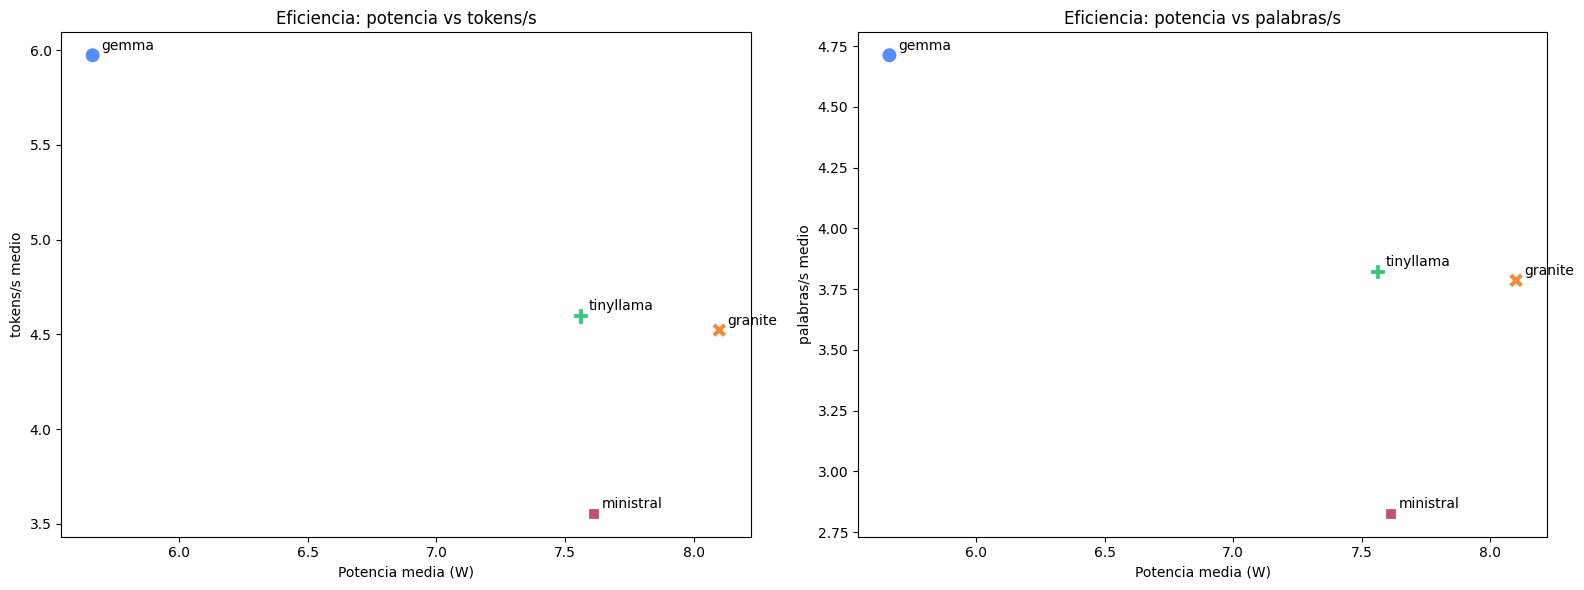

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_col, y_label, title in [
    (axes[0], "tokens_per_s_mean", "tokens/s medio",
     "Eficiencia: potencia vs tokens/s"),
    (axes[1], "words_per_s_mean", "palabras/s medio",
     "Eficiencia: potencia vs palabras/s"),
]:
    sns.scatterplot(
        data=summary, x="power_mean_w", y=y_col,
        hue="model_label", style="model_label",
        s=120, ax=ax, legend=False,
    )
    for _, row in summary.iterrows():
        ax.annotate(
            row["model_label"],
            xy=(row["power_mean_w"], row[y_col]),
            xytext=(6, 4), textcoords="offset points",
            fontsize=10, ha="left",
        )
    ax.set_xlabel("Potencia media (W)")
    ax.set_ylabel(y_label)
    ax.set_title(title)

fig.tight_layout()
plt.show()


## Energía por token

Coste energético de generar un solo token. Es la métrica más honesta
para comparar modelos de tamaños distintos porque normaliza por
rendimiento. Un valor más bajo es mejor.

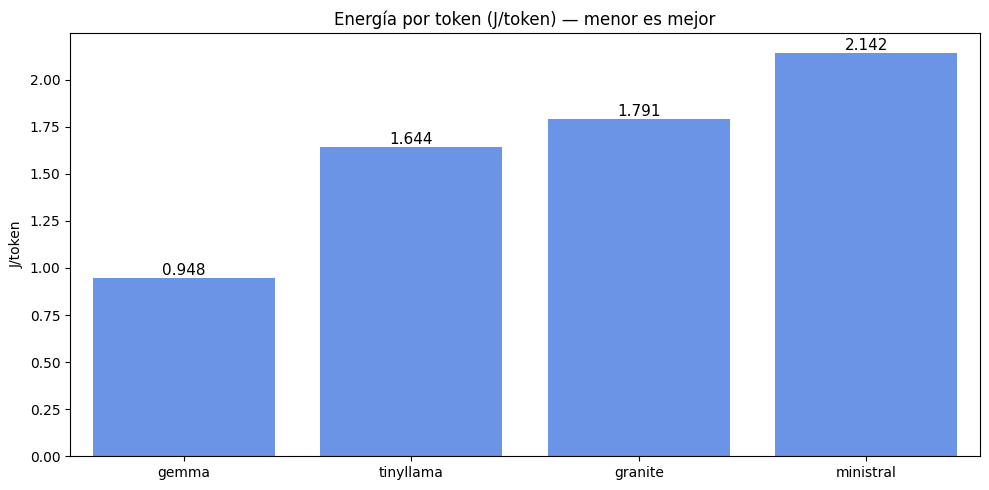

In [7]:
energy = summary.dropna(subset=["energy_per_token_j"]).sort_values("energy_per_token_j")
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=energy, x="model_label", y="energy_per_token_j", ax=ax)
ax.set_title("Energía por token (J/token) — menor es mejor")
ax.set_xlabel("")
ax.set_ylabel("J/token")
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.3f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=11,
    )
fig.tight_layout()
plt.show()


## Régimen térmico comparado

Temperatura máxima alcanzada y potencia máxima por modelo. Útil para
evaluar la viabilidad de despliegue sostenido en hardware sin
refrigeración activa.

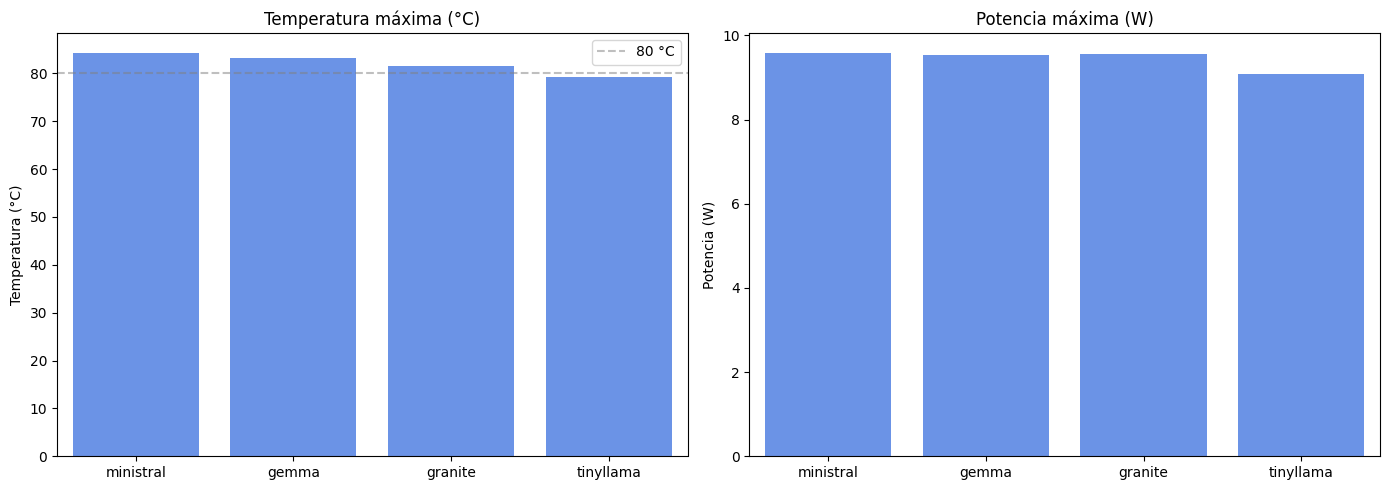

In [8]:
thermal = summary.dropna(subset=["temp_max_c"])
if thermal.empty:
    print("No hay datos de hardware para ningún run.")
else:
    order = thermal.sort_values("temp_max_c", ascending=False)["model_label"].tolist()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(data=thermal, x="model_label", y="temp_max_c",
                order=order, ax=axes[0])
    axes[0].set_title("Temperatura máxima (°C)")
    axes[0].axhline(80, ls="--", color="gray", alpha=0.5, label="80 °C")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Temperatura (°C)")
    axes[0].legend()

    sns.barplot(data=thermal, x="model_label", y="power_max_w",
                order=order, ax=axes[1])
    axes[1].set_title("Potencia máxima (W)")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Potencia (W)")

    fig.tight_layout()
    plt.show()


## Alertas y anomalías

Resumen de runs con problemas potenciales: throttling, generaciones
vacías, configs distintas al grueso del experimento.

In [9]:
alerts = []

throttled = summary[summary["throttled_ratio"] > 0]
if not throttled.empty:
    for _, row in throttled.iterrows():
        alerts.append(
            f"\u26a0\ufe0f  {row['model_label']}: {row['throttled_ratio']*100:.1f}% "
            f"de muestras con throttling activo."
        )

empty_gens = summary[summary["n_empty_generations"] > 0]
if not empty_gens.empty:
    for _, row in empty_gens.iterrows():
        alerts.append(
            f"\u2139\ufe0f  {row['model_label']}: {int(row['n_empty_generations'])}/"
            f"{int(row['n_prompts'])} prompts con generaci\u00f3n vac\u00eda."
        )

configs = summary[["batch_size", "context_size", "temperature"]].drop_duplicates()
if len(configs) > 1:
    alerts.append(
        "\u26a0\ufe0f  Hay runs con configuraciones distintas (batch_size, context_size "
        "o temperature). Las comparativas directas entre estos runs est\u00e1n "
        "confundidas por m\u00faltiples variables."
    )

if alerts:
    for a in alerts:
        print(a)
else:
    print("\u2705 Sin alertas.")


⚠️  gemma: 21.7% de muestras con throttling activo.
⚠️  ministral: 28.0% de muestras con throttling activo.
ℹ️  tinyllama: 3/7 prompts con generación vacía.


> **Nota metodológica**: el ratio de throttling expresa el porcentaje de
> muestras de hardware con alguna flag activa (`under_voltage`, `freq_capped`,
> `throttled` o `soft_throttled`) durante **este run concreto**. No es una
> propiedad intrínseca del modelo. A igual duración y condiciones térmicas
> iniciales, la comparativa entre modelos es válida. Runs más largos o con
> temperatura ambiente más alta tenderán a un ratio mayor.


## Resumen para la memoria

Texto generado automáticamente con los hallazgos principales,
listo para integrar en la sección de resultados del TFG.

In [10]:
s = summary.sort_values("tokens_per_s_mean", ascending=False)

lines = [
    f"Se han evaluado {len(s)} configuraciones modelo/motor sobre Raspberry Pi 5.",
    "",
    "**Throughput (tokens/s, de mayor a menor):**",
]
for _, row in s.iterrows():
    tps = row.get("tokens_per_s_mean", float("nan"))
    wps = row.get("words_per_s_mean", float("nan"))
    lines.append(
        f"  - {row['model_label']} ({row['engine']}): "
        f"{tps:.2f} tokens/s, {wps:.2f} palabras/s"
    )

lines.append("")
energy_col = "energy_per_token_j"
if energy_col in s.columns and s[energy_col].notna().any():
    best = s.loc[s[energy_col].idxmin()]
    worst = s.loc[s[energy_col].idxmax()]
    lines.append(
        f"**Eficiencia energ\u00e9tica**: el m\u00e1s eficiente es "
        f"{best['model_label']} ({best[energy_col]:.4f} J/token), "
        f"el menos eficiente es {worst['model_label']} "
        f"({worst[energy_col]:.4f} J/token)."
    )

lines.append("")
throttled = summary[summary["throttled_ratio"] > 0]
if throttled.empty:
    lines.append("**Throttling**: ning\u00fan run present\u00f3 throttling.")
else:
    names = ", ".join(throttled["model_label"].tolist())
    lines.append(f"**Throttling**: detectado en {names}.")

for line in lines:
    print(line)


Se han evaluado 4 configuraciones modelo/motor sobre Raspberry Pi 5.

**Throughput (tokens/s, de mayor a menor):**
  - gemma (OLLAMA): 5.97 tokens/s, 4.71 palabras/s
  - tinyllama (LLAMA): 4.60 tokens/s, 3.82 palabras/s
  - granite (OLLAMA): 4.52 tokens/s, 3.79 palabras/s
  - ministral (OLLAMA): 3.55 tokens/s, 2.83 palabras/s

**Eficiencia energética**: el más eficiente es gemma (0.9483 J/token), el menos eficiente es ministral (2.1418 J/token).

**Throttling**: detectado en gemma, ministral.


## Rendimiento vs arquitectura del modelo

Relación entre métricas de rendimiento y parámetros de arquitectura.
Disponible solo para los modelos que tienen `model_info` exportado por
el MonitorSystem.

- **TTFT vs embedding_length**: el prefill procesa el prompt con la
  dimensión del embedding; mayor embedding → más cómputo por token.
- **tokens/s vs n_params**: la velocidad de decode escala inversamente
  con el número de parámetros a igual hardware.
- **TTLM vs n_params**: cargar el modelo desde disco depende de su
  tamaño total en bytes.


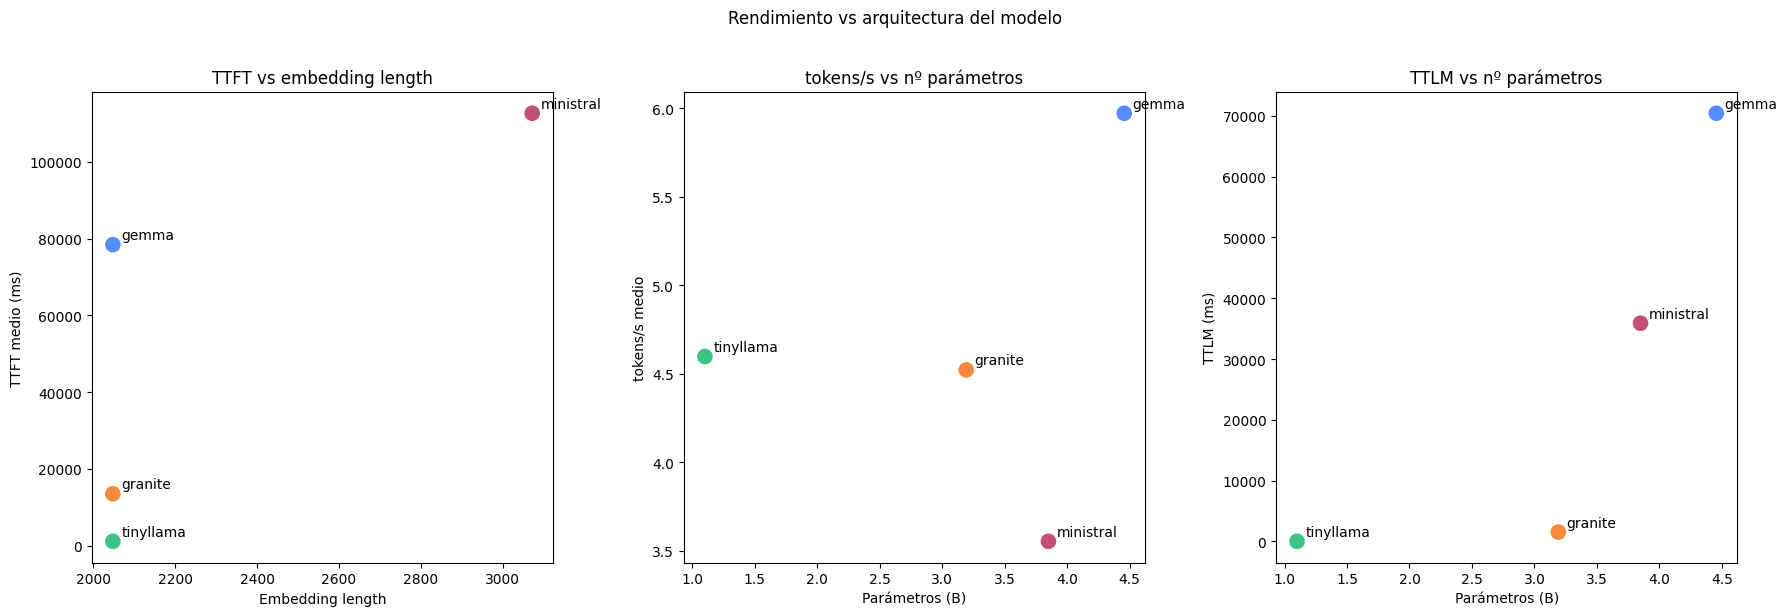

In [11]:
arch_data = summary.dropna(subset=["n_params_from_info", "embedding_length_from_info"], how="all") if "n_params_from_info" in summary.columns else summary.iloc[:0]

# Extraer campos de model_info al summary_df si no están ya como columnas
if "n_params_from_info" not in summary.columns:
    summary["n_params_from_info"] = [
        r.summary.model_info.get("n_params") if r.summary.model_info else None
        for r in coll.runs
    ]
    summary["embedding_length_from_info"] = [
        r.summary.model_info.get("embedding_length") if r.summary.model_info else None
        for r in coll.runs
    ]
    # TTLM: load_duration_ns del primer prompt no vacío
    ttlm_list = []
    for r in coll.runs:
        non_empty = [p for p in r.prompts if not p.is_empty_generation]
        ttlm = non_empty[0].load_duration_ns / 1e6 if non_empty else None
        ttlm_list.append(ttlm)
    summary["ttlm_ms"] = ttlm_list

arch_data = summary.dropna(
    subset=["n_params_from_info", "embedding_length_from_info"]
).copy()
arch_data["n_params_b"] = arch_data["n_params_from_info"] / 1e9

if arch_data.empty:
    print(
        "Sin datos de arquitectura. Requiere runs con model_info "
        "(MonitorSystem actualizado)."
    )
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 1) TTFT vs embedding_length
    ax = axes[0]
    sns.scatterplot(data=arch_data, x="embedding_length_from_info",
                    y="ttft_ms_mean", hue="model_label",
                    s=150, ax=ax, legend=False)
    for _, row in arch_data.iterrows():
        ax.annotate(row["model_label"],
                    (row["embedding_length_from_info"], row["ttft_ms_mean"]),
                    xytext=(6, 4), textcoords="offset points", fontsize=10)
    ax.set_title("TTFT vs embedding length")
    ax.set_xlabel("Embedding length")
    ax.set_ylabel("TTFT medio (ms)")

    # 2) tokens/s vs n_params (en billones)
    ax = axes[1]
    sns.scatterplot(data=arch_data, x="n_params_b",
                    y="tokens_per_s_mean", hue="model_label",
                    s=150, ax=ax, legend=False)
    for _, row in arch_data.iterrows():
        ax.annotate(row["model_label"],
                    (row["n_params_b"], row["tokens_per_s_mean"]),
                    xytext=(6, 4), textcoords="offset points", fontsize=10)
    ax.set_title("tokens/s vs nº parámetros")
    ax.set_xlabel("Parámetros (B)")
    ax.set_ylabel("tokens/s medio")

    # 3) TTLM vs n_params
    ax = axes[2]
    ttlm_data = arch_data.dropna(subset=["ttlm_ms"])
    if not ttlm_data.empty:
        sns.scatterplot(data=ttlm_data, x="n_params_b",
                        y="ttlm_ms", hue="model_label",
                        s=150, ax=ax, legend=False)
        for _, row in ttlm_data.iterrows():
            ax.annotate(row["model_label"],
                        (row["n_params_b"], row["ttlm_ms"]),
                        xytext=(6, 4), textcoords="offset points", fontsize=10)
    ax.set_title("TTLM vs nº parámetros")
    ax.set_xlabel("Parámetros (B)")
    ax.set_ylabel("TTLM (ms)")

    fig.suptitle("Rendimiento vs arquitectura del modelo", y=1.02)
    fig.tight_layout()
    plt.show()
